# BÀI TẬP VỀ NHÀ: RNN

## Bài tập 1: Dự báo chuỗi thời gian đa biến

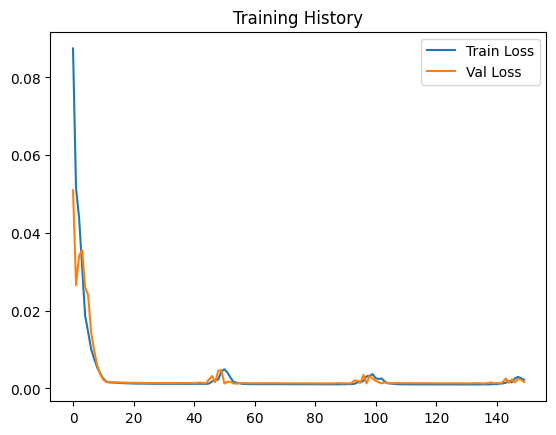

Test MSE: 0.00219, Test MAE: 0.03747


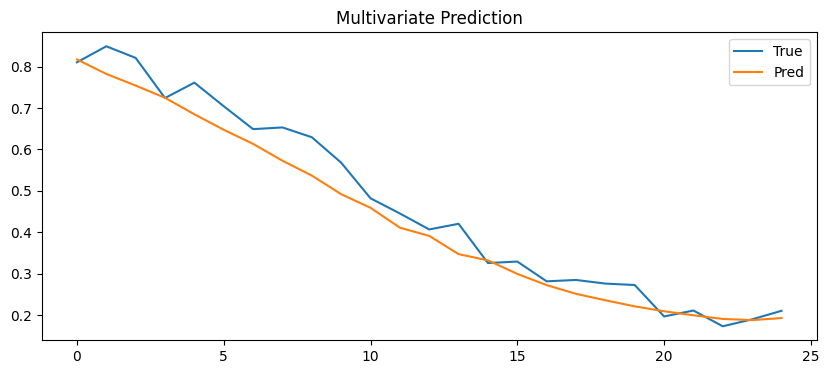

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
torch.manual_seed(42)

# Hàm tạo chuỗi dữ liệu (Dùng chung cho các bài tập)
def create_sequences(series, seq_length):
    X, y = [], []
    for i in range(len(series) - seq_length):
        X.append(series[i : i + seq_length])
        y.append(series[i + seq_length])
    return torch.stack(X) if isinstance(X[0], torch.Tensor) else torch.FloatTensor(np.array(X)), \
           torch.stack(y) if isinstance(y[0], torch.Tensor) else torch.FloatTensor(np.array(y))

# 1. Sinh dữ liệu đa biến
time_steps = 300
t = np.linspace(0, 30, time_steps)
feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target
})

# 2. Tiền xử lý (Phần A)
train_idx = int(len(df) * 0.7)
val_idx = int(len(df) * 0.85)

train_df = df.iloc[:train_idx]
val_df = df.iloc[train_idx:val_idx]
test_df = df.iloc[val_idx:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

def create_multivariate_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1]) # Lấy 3 features đầu
        y.append(data[i+seq_length, -1])    # Lấy target cuối
    return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y)).unsqueeze(1)

seq_length = 20
X_train, y_train = create_multivariate_sequences(train_scaled, seq_length)
X_val, y_val = create_multivariate_sequences(val_scaled, seq_length)
X_test, y_test = create_multivariate_sequences(test_scaled, seq_length)

# 3. Mô hình (Phần B)
class MultivariateRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, dropout=0.0):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

model = MultivariateRNN(input_size=3, hidden_size=32, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=False)
epochs = 150
history = {'train_loss': [], 'val_loss': []}

for epoch in range(epochs):
    model.train()
    t_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * xb.size(0)

    model.eval()
    with torch.no_grad():
        v_pred = model(X_val)
        v_loss = criterion(v_pred, y_val)

    history['train_loss'].append(t_loss/len(X_train))
    history['val_loss'].append(v_loss.item())

plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Training History"); plt.show()

# 4. Đánh giá (Phần C)
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    mse = criterion(test_pred, y_test).item()
    mae = torch.abs(test_pred - y_test).mean().item()
    print(f"Test MSE: {mse:.5f}, Test MAE: {mae:.5f}")

plt.figure(figsize=(10,4))
plt.plot(y_test.numpy(), label='True')
plt.plot(test_pred.numpy(), label='Pred')
plt.legend(); plt.title("Multivariate Prediction"); plt.show()

## Bài tập 2: Quan sát hiện tượng vanishing gradient

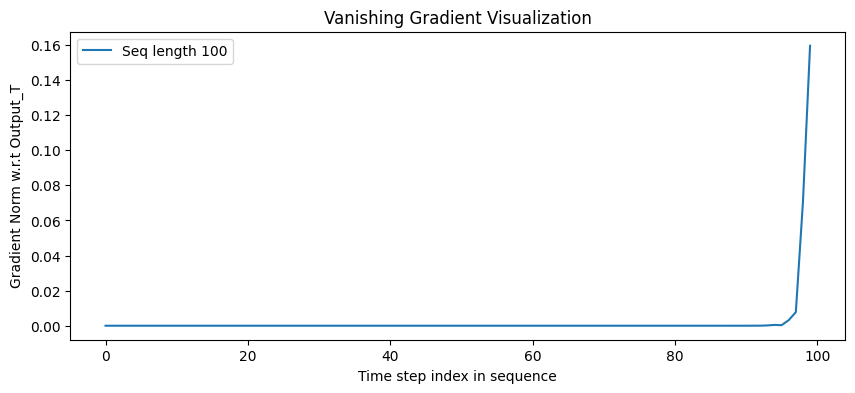

Nhận xét: Gradient ở các bước thời gian đầu cực kỳ nhỏ so với các bước cuối, minh họa hiện tượng vanishing gradient.


In [2]:
def study_vanishing_gradient(seq_len):
    # Sinh dữ liệu
    t = np.linspace(0, 100, 1000)
    data = torch.FloatTensor(np.sin(t)).unsqueeze(1)
    X, y = create_sequences(data, seq_len)

    model = nn.RNN(input_size=1, hidden_size=8, batch_first=True)

    # Một mẫu batch size 1 để dễ quan sát
    sample_x = X[0:1]
    sample_x.requires_grad = True
    output, h_n = model(sample_x)

    norms = []
    for t in range(seq_len):
        model.zero_grad()
        if sample_x.grad is not None: sample_x.grad.zero_()
        # Tính gradient của output tại bước cuối cùng đối với input tại bước t
        output[0, -1, 0].backward(retain_graph=True)
        grad_norm = torch.norm(sample_x.grad[0, t, :]).item()
        norms.append(grad_norm)

    return norms

norms_100 = study_vanishing_gradient(100)

plt.figure(figsize=(10,4))
plt.plot(norms_100, label='Seq length 100')
plt.xlabel('Time step index in sequence'); plt.ylabel('Gradient Norm w.r.t Output_T')
plt.title("Vanishing Gradient Visualization")
plt.legend(); plt.show()

print("Nhận xét: Gradient ở các bước thời gian đầu cực kỳ nhỏ so với các bước cuối, minh họa hiện tượng vanishing gradient.")

## Bài tập 3: So sánh RNN với baseline

In [3]:
class MLP(nn.Module):
    def __init__(self, input_size=10, hidden_size=20, output_size=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

# Tạo data đơn biến
t_data = torch.FloatTensor(np.sin(np.linspace(0, 20, 200))).unsqueeze(1)
X_s, y_s = create_sequences(t_data, 10)
X_te, y_te = X_s[150:], y_s[150:]

# Train ANN nhanh
ann_m = MLP(10, 20, 1)
optimizer_ann = torch.optim.Adam(ann_m.parameters(), lr=0.01)
for _ in range(50):
    ann_m.train()
    optimizer_ann.zero_grad()
    p = ann_m(X_s[:150])
    l = nn.MSELoss()(p, y_s[:150])
    l.backward(); optimizer_ann.step()

ann_m.eval()
with torch.no_grad():
    ann_pred = ann_m(X_te)
    mse_ann = nn.MSELoss()(ann_pred, y_te).item()

naive_p = X_te[:, -1, 0]
mse_naive = np.mean((naive_p.numpy() - y_te.squeeze().numpy())**2)

print(f"MSE Results:")
print(f"- ANN (MLP): {mse_ann:.5f}")
print(f"- Naive:     {mse_naive:.5f}")

MSE Results:
- ANN (MLP): 0.00097
- Naive:     0.00519
